# Session 2 - NumPy / Pandas / Seaborn

**Plan for today**
1. NumPy warm-up
2. Pandas I - loading, cleaning, filtering, groupby
3. Pandas II - merging, pivoting, resampling
4. Seaborn - visualizing the data
5. Extending `EDAReport` with real analysis methods

Today's data is **real**: actual orders from Olist, a Brazilian e-commerce marketplace
(Sep 2016 - Oct 2018), split across several files the way real company data usually is,
plus real historical BRL->EUR exchange rates. Nothing here is simulated. Part of today's work
is exactly what it would be on the job: joining files that don't share a single clean schema,
and noticing (not ignoring) the missing values and rough edges real data always has.

Five files, all in the same folder as this notebook:
- `olist_orders.csv` - one row per order (status, purchase date)
- `olist_order_items.csv` - one row per item within an order (price, freight cost)
- `olist_products.csv` - one row per product (category, in Portuguese)
- `product_category_translation.csv` - Portuguese -> English category name lookup
- `brl_eur_rates.csv` - real monthly BRL->EUR exchange rates for this exact period

As before: **core** exercises are for everyone, **advanced** ones are bonus/optional.


In [1]:
# Run this first
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)


## 1. NumPy warm-up

### Exercise 1.1 (core) - Vectorize a loop
<details>
<summary>Vectorizing a loop means replacing an explicit Python loop with an operation that processes many values at once, typically using a library like NumPy.</summary>
Suppose we need to double all values in a list.

*Without vectorization*
```python
numbers = [1, 2, 3, 4, 5]

result = []
for x in numbers:
    result.append(x * 2)
```
*With vectorization using NumPy*
```python
import numpy as np

numbers = np.array([1, 2, 3, 4, 5])

result = numbers * 2
```
Vectorization means you express the operation as an operation on the whole array, allowing optimized library code (often implemented in compiled languages) to handle the looping efficiently.
</details>

Given parallel arrays of `prices` and `quantities` (one entry per line item), compute `revenue`
for each - first with a plain Python loop, then again with a single **vectorized** NumPy expression.
Confirm both give the same result.


In [2]:
prices = np.array([58.90, 239.90, 199.00, 12.99, 89.50, 45.00])
quantities = np.array([1, 1, 2, 5, 1, 3])

revenue_loop = []
for p, q in zip(prices, quantities):
    revenue_loop.append(p * q)

revenue_vectorized = prices * quantities

print(revenue_loop)
print(revenue_vectorized)


[np.float64(58.9), np.float64(239.9), np.float64(398.0), np.float64(64.95), np.float64(89.5), np.float64(135.0)]
[ 58.9  239.9  398.    64.95  89.5  135.  ]


In [3]:
assert np.allclose(revenue_loop, revenue_vectorized)
assert revenue_vectorized[2] == 398.0
print("Looks good!")


Looks good!


### Exercise 1.2 (core) - Stats along an axis

`sales_matrix` below has one **row per product category** and one **column per month** (number
of orders that month).

1. Compute the **overall** mean of all values.
2. Compute the mean **per category** (across months) - one value per row, using `axis=1`.
3. Compute the total **per month** (across categories) - one value per column, using `axis=0`.


In [4]:
sales_matrix = np.array(
    [
        [120, 135, 150, 128, 140, 160],
        [80, 95, 70, 85, 90, 100],
        [200, 210, 190, 220, 205, 230],
    ]
)

overall_mean = sales_matrix.mean()
mean_per_category = sales_matrix.mean(axis=1)
total_per_month = sales_matrix.sum(axis=0)

print(overall_mean)
print(mean_per_category)
print(total_per_month)


144.88888888888889
[138.83333333  86.66666667 209.16666667]
[400 440 410 433 435 490]


In [5]:
assert mean_per_category.shape == (3,)
assert total_per_month.shape == (6,)
assert round(mean_per_category[0], 2) == 138.83
print("Looks good!")


Looks good!


### Exercise 1.3 (advanced) - Broadcasting: normalize a matrix
<details>
<summary>In NumPy, <b>Broadcasting</b> is the mechanism that allows some differently shaped arrays to participate in the same element-wise operation.</summary>

Simple example:
```python
import numpy as np

numbers = np.array([1, 2, 3, 4])

numbers + 10
```
Output
```python
array([11, 12, 13, 14])
```
You only provided one 10, but NumPy effectively applies it to every element

Vectorization and broadcasting are closely related:

- Vectorization lets us express the calculation as operations on whole arrays
- Broadcasting allows those operations to work when the operands have compatible but different shapes.
</details>


Using `sales_matrix` again, produce a **standardized** version where each row has had its own
row-mean subtracted, then divided by the *column* standard deviations - all without loops,
relying purely on broadcasting.


In [6]:
row_means = sales_matrix.mean(axis=1, keepdims=True)
col_stds = sales_matrix.std(axis=0)
standardized = (sales_matrix - row_means) / col_stds

print(standardized)


[[-0.3775065  -0.08041761  0.22383129 -0.19238517  0.02477973  0.39843444]
 [-0.13363062  0.1748209  -0.33407655 -0.02959772  0.07079923  0.25098232]
 [-0.1837421   0.01748209 -0.38418804  0.19238517 -0.08849904  0.39215988]]


## 2. Pandas I - loading, cleaning, filtering, groupby

### Setup - loading today's data

Load all five files. Don't merge anything yet - just get a first look at each one on its own.


In [7]:
orders = pd.read_csv("olist_orders.csv")
order_items = pd.read_csv("olist_order_items.csv")
products = pd.read_csv("olist_products.csv")
category_translation = pd.read_csv("product_category_translation.csv")
fx = pd.read_csv("brl_eur_rates.csv")

for name, df in [
    ("orders", orders),
    ("order_items", order_items),
    ("products", products),
    ("category_translation", category_translation),
    ("fx", fx),
]:
    print(f"{name}: {df.shape}")

orders.head()


orders: (99441, 4)
order_items: (112650, 5)
products: (32951, 2)
category_translation: (71, 2)
fx: (26, 2)


,order_id,customer_id,order_status,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39


### The schema, at a glance

Olist publishes an entity-relationship diagram showing how all nine of its tables connect —
useful orientation before merging anything, the way you'd often be handed a schema diagram for
an unfamiliar database at a real job. We're only using four of these tables today (`orders`,
`order_items`, `products`, plus the category translation lookup, which isn't ID-based so it
doesn't appear on this diagram the way the others do) — the rest (`sellers`, `reviews`,
`payments`, `geolocation`, `customers`) are there if you want to explore further on your own.

Full dataset, all nine files, and more detail: [Olist Brazilian E-Commerce dataset on
Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce).

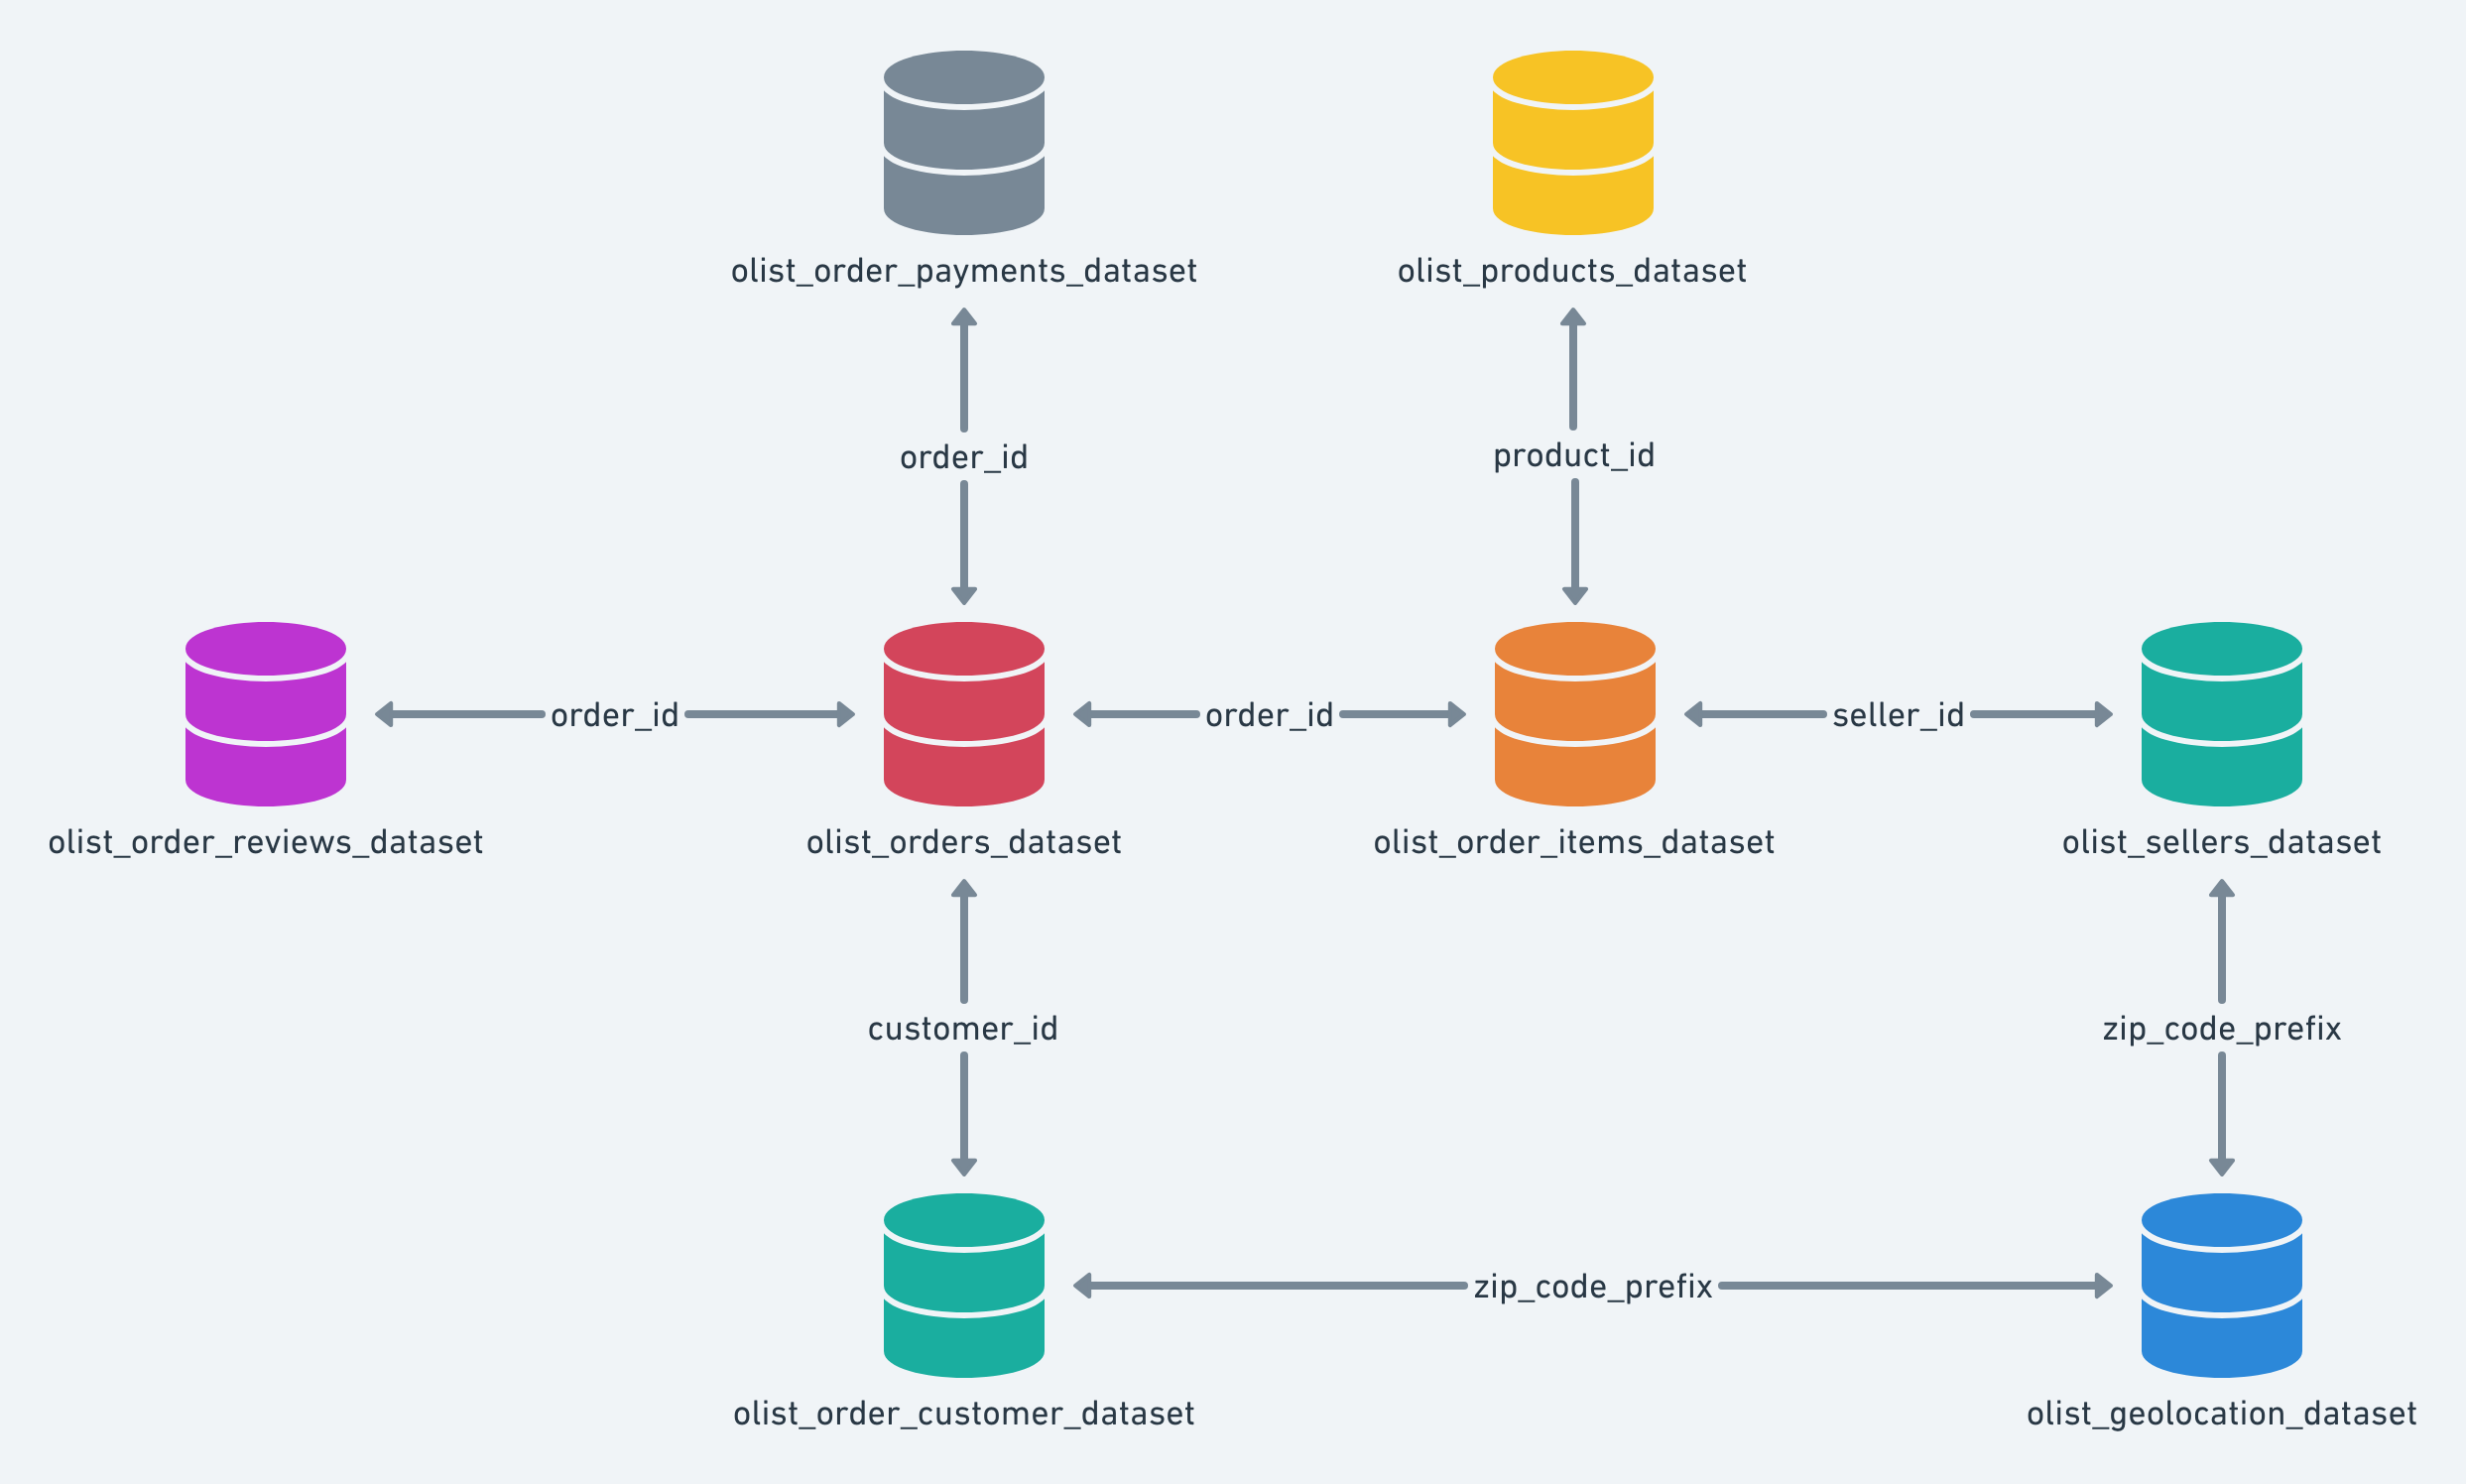



### Exercise 2.1 (core) - Inspect `orders`
<details>
<summary>Take a look at the orders dataframe to look for any anomaly or issue.</summary>
There are several ways to take a glimpse at a dataframe, depending on what you are looking for.

```python
df.shape
df.info()
df.head()
df.describe()
```
</details>


- How many rows and columns are there?
- What are the column names?
- What data type does each column have? Are they what you expected?
- Are there missing values?


In [8]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   order_id                  99441 non-null  str  
 1   customer_id               99441 non-null  str  
 2   order_status              99441 non-null  str  
 3   order_purchase_timestamp  99441 non-null  str  
dtypes: str(4)
memory usage: 3.0 MB


`order_purchase_timestamp` was loaded as a string instead of a datetime object.

Parse `order_purchase_timestamp` as a real datetime,

In [ ]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

Now take a look at the distribution (frequency of each value) of `order_status` using `value_counts()`([see documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html#pandas.Series.value_counts))


In [ ]:
status_counts = orders["order_status"].value_counts()

print(orders.dtypes)
print(status_counts)

order_id                               str
customer_id                            str
order_status                           str
order_purchase_timestamp    datetime64[us]
dtype: object
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


### Exercise 2.2 (core) - Attach English category names, and find the gaps
`products` has a `product_category_name` in **Portuguese**. `category_translation` maps those
to English. 
<details>
<summary>Merge them together, then check for **two different kinds of missing data**:

1. Products with **no category at all** (`product_category_name` is null).
2. Products that **do** have a category, but that category has **no English translation**
   in the lookup table (a genuine mismatch between the two files, not something we introduced).
</summary>
In pandas, <code>merge()</code> combines two DataFrames based on one or more columns they have in common. It is similar to a SQL JOIN.

Suppose you have a table <code>customers</code>

| customer_id | name    |
| ----------- | ------- |
| 101         | Alice   |
| 102         | Bob     |
| 103         | Charlie |

And a table <code>orders</code>

| customer_id | order_value |
| ----------- | ----------: |
| 101         |         250 |
| 102         |         180 |
| 101         |         320 |

You can merge them using <code>customer_id</code>

```python
df = customers.merge(orders, on="customer_id")
```

Giving you

| customer_id | name  | order_value |
| ----------- | ----- | ----------: |
| 101         | Alice |         250 |
| 102         | Bob   |         180 |
| 101         | Alice |         320 |

</details>

In [10]:
products_en = pd.merge(
    products, category_translation, on="product_category_name", how="left"
)

n_no_category = products_en["product_category_name"].isna().sum()
n_no_translation = (
    products_en.loc[
        products_en["product_category_name"].notna(), "product_category_name_english"
    ]
    .isna()
    .sum()
)

print(f"No category at all: {n_no_category}")
print(f"Category exists but untranslated: {n_no_translation}")


No category at all: 610
Category exists but untranslated: 13


In [11]:
assert n_no_category == 610
assert n_no_translation == 13
print(
    "Looks good! Two genuinely different data-quality issues, worth keeping distinct."
)


Looks good! Two genuinely different data-quality issues, worth keeping distinct.


### Exercise 2.3 (core) - Merge orders with their items

Merge `order_items` with `orders` on `order_id` (`how="left"`, keeping every item) so each line
item carries its order's status and purchase date. Then filter to `order_status == "delivered"`
only - the completed sales we identified in 2.1 - into `delivered`.


In [12]:
order_items_full = pd.merge(order_items, orders, on="order_id", how="left")

delivered = order_items_full[order_items_full["order_status"] == "delivered"].copy()

print(order_items_full.shape)
print(delivered.shape)


(112650, 8)
(110197, 8)


In [13]:
assert "order_status" in order_items_full.columns
assert (delivered["order_status"] == "delivered").all()
print("Looks good!")


Looks good!


### Exercise 2.4 (advanced) - Chain it with `.pipe()`

Rewrite Exercise 2.3's merge-then-filter as a **single chained pipeline** using `.pipe()` with
small named functions, starting from the raw `order_items` and `orders` DataFrames.

> **"Small, named functions" means single-responsibility functions** — each one does exactly
> one clearly-nameable thing, nothing bundled in on the side.
>
> #### Why it matters specifically for `.pipe()` chains
> - **Composability**: small functions can be reordered, reused elsewhere, or swapped out
>   independently. If `filter_delivered` also did the merge internally, you couldn't reuse
>   just the filtering logic somewhere else.
> - **Readability of the chain itself**: `order_items.pipe(merge_with_orders, orders).pipe(filter_delivered)`
>   reads almost like a sentence — each step name tells you what just happened. If a step did
>   three things, the step's name would either be vague (`process_data`) or misleadingly narrow.
> - **Testability**: a function that does one thing is easy to check in isolation — pass it a
>   small hand-made DataFrame, assert the output. A function that merges *and* filters *and*
>   renames is harder to test precisely, because you can't isolate which part broke.
>
> #### The line not to over-cross
> "Small" doesn't mean "trivial to the point of pointlessness" — a one-line function that just
> wraps `df.dropna()` with no real added meaning isn't buying you much. The bar is closer to:
> *does this function have a name that fully and accurately describes everything it does,
> without an "and" in the middle?* If you'd have to name it `merge_and_filter_and_rename`,
> that's the signal to split it.


In [14]:
def merge_with_orders(items_df, orders_df):
    return pd.merge(items_df, orders_df, on="order_id", how="left")


def filter_delivered(df):
    return df[df["order_status"] == "delivered"]


result = order_items.pipe(merge_with_orders, orders).pipe(filter_delivered)

print(result.shape)


(110197, 8)


## 3. Pandas II - merging, pivoting, resampling

We want to know the price in EUR of the various orders found in the `orders` dataframe. To get this price, we will need to use external data to know the conversion rates at the time.

You can find that information inside the `fx` dataframe.

### Exercise 3.1 (core) - Looking at the BRL-EUR conversion rate
Have a quick look at the data found in the `fx` dataframe. (info/head)

What is the granularity of the data?

In [16]:
fx.info()
fx.head()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    26 non-null     str    
 1   rate    26 non-null     float64
dtypes: float64(1), str(1)
memory usage: 548.0 bytes


,date,rate
0,2016-09-01,0.27422
1,2016-10-01,0.28385
2,2016-11-01,0.27713
3,2016-12-01,0.28179
4,2017-01-01,0.29388


### Exercise 3.2 (core) - Parse `fx`'s `date` column as datetime
You already did the same operation in section 2.1 on the `orders` dataframe.

In [ ]:
fx["date"] = pd.to_datetime(fx["date"])


### Exercise 3.3 (core) - Bring in categories, then convert to EUR

1. Merge `delivered` (from 2.3) with `products_en` (from 2.2) on `product_id`, so each item has
   its English category name.

What is the granularity of the data here?


In [20]:
final = pd.merge(delivered, products_en, on="product_id", how="left")

We have the exact date of purchase for each order but only have **monthly** rates so we have to do some *feature engineering*.

2. Derive a `month` column from `order_purchase_timestamp` - the first day of that month
   (`.dt.to_period("M").dt.to_timestamp()`).

In [21]:
final["month"] = final["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

3. Merge the `final` and `fx` dataframes on the appropriate column.

In [24]:
final = pd.merge(final, fx, left_on="month", right_on="date", how="left")

4. Compute `price_eur = price * rate`.

In [25]:
final["price_eur"] = final["price"] * final["rate"]

print(final["rate"].isna().sum())
final[
    ["order_id", "product_category_name_english", "price", "rate", "price_eur"]
].head()


0


,order_id,product_category_name_english,price,rate,price_eur
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,58.90,0.26757,15.759873
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,239.90,0.29718,71.293482
2,000229ec398224ef6ca0657da4fc703e,furniture_decor,199.00,0.25524,50.792760
3,00024acbcdf0a6daa1e931b038114c75,perfumery,12.99,0.22124,2.873908
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools,199.90,0.30212,60.393788


5. Drop the now-redundant `date` column (duplicate of `month`, left over from the merge).


In [ ]:
final = final.drop(columns=["date"])


In [26]:
assert final["rate"].isna().sum() == 0
assert "price_eur" in final.columns
assert "date" not in final.columns
print("Looks good!")


Looks good!


### Exercise 3.4 (core) - Top categories by revenue
Your next objective is to find the top10 performing product categories.

Group `final` by `product_category_name_english`, sum `price_eur`, sort descending, and look at
the top 10. There are 71 categories total - for the plots in section 4, we'll focus on just the
top few rather than trying to show all of them at once.


In [27]:
category_revenue = (
    final.groupby("product_category_name_english")["price_eur"]
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue.head(10))


product_category_name_english
health_beauty            307998.582626
watches_gifts            292134.260708
bed_bath_table           259788.965317
sports_leisure           243002.042776
computers_accessories    226580.487835
furniture_decor          181216.056900
cool_stuff               158898.556159
housewares               153023.366815
auto                     145467.048177
toys                     121731.660279
Name: price_eur, dtype: float64


### Exercise 3.5 (core) - Pivot table: revenue by month and category
Next, we want the monthly total revenue in EUR for the top6 product categories.

Take the **top 6** categories from 3.4 (`category_revenue.head(6).index`), filter `final` down to
just those, and build a pivot table of total `price_eur` with `month` as rows and category as
columns.


In [29]:
top6_categories = category_revenue.head(6).index

final_top6 = final[final["product_category_name_english"].isin(top6_categories)]

revenue_pivot = pd.pivot_table(
    final_top6,
    values="price_eur",
    index="month",
    columns="product_category_name_english",
    aggfunc="sum",
)

print(revenue_pivot)


product_category_name_english  bed_bath_table  computers_accessories  \
month                                                                  
2016-09-01                                NaN                    NaN   
2016-10-01                         135.961311             189.901327   
2017-01-01                        1118.025317            1153.226263   
2017-02-01                        4704.651916            3419.723471   
2017-03-01                        7514.653983            8399.773020   
2017-04-01                        7159.925050            5454.281243   
2017-05-01                        9232.418962           12643.184893   
2017-06-01                        9151.210426            9798.358464   
2017-07-01                       17000.197290           10336.593327   
2017-08-01                       15209.439150            9092.893401   
2017-09-01                       13941.898068            7502.836720   
2017-10-01                       12264.272589           11198.44

### Exercise 3.6 (core) - Monthly revenue trend, and a real gap
We want to look at total monthly revenue now.

Group `final` by `month` and sum `price_eur` to get total monthly revenue. Then **reindex** it
against a complete month range (`pd.period_range("2016-09", "2018-10", freq="M").to_timestamp()`)
so any month with *zero* delivered revenue shows up explicitly as `NaN` instead of silently
disappearing from the series.

Real data often has gaps like this - a platform ramping up, or a reporting period that just
isn't fully covered. Missing months look identical to "nothing happened" unless you deliberately
check for them.


In [30]:
monthly_revenue = final.groupby("month")["price_eur"].sum()

all_months = pd.period_range("2016-09", "2018-10", freq="M").to_timestamp()
monthly_revenue_full = monthly_revenue.reindex(all_months)

print(monthly_revenue_full)
# Three months come back NaN: Nov 2016 and the last two months of the dataset (Sep/Oct 2018) --
# genuine gaps in Olist's coverage at the edges of the period, not a bug in this merge.


2016-09-01        37.011473
2016-10-01     11446.282473
2016-11-01              NaN
2016-12-01         3.071511
2017-01-01     32855.302037
2017-02-01     70763.573608
2017-03-01    107454.335978
2017-04-01    101240.215502
2017-05-01    138223.375477
2017-06-01    114223.094726
2017-07-01    130399.239835
2017-08-01    149108.826357
2017-09-01    162521.929702
2017-10-01    172803.376060
2017-11-01    258024.069951
2017-12-01    186242.033899
2018-01-01    236006.389800
2018-02-01    206129.948965
2018-03-01    236136.809562
2018-04-01    233249.032623
2018-05-01    228100.277965
2018-06-01    194218.384098
2018-07-01    194022.316448
2018-08-01    185526.695834
2018-09-01              NaN
2018-10-01              NaN
Freq: MS, Name: price_eur, dtype: float64


In [19]:
assert monthly_revenue_full.isna().sum() == 3
print("Looks good!")


Looks good!


### Exercise 3.7 (advanced) - Decide what to do about the gaps

`monthly_revenue_full` (from 3.6) has 3 `NaN` months. Before plotting or analyzing a time series
with gaps, you have to make an explicit, defensible choice about what they mean:
- **Leave them as `NaN`** - honest, but breaks a line plot into disconnected segments.
- **Forward-fill** (`.ffill()`) - assumes "same as last known month," which is a real assumption,
  not a neutral default.
- **Fill with 0** - only correct if you're confident the gap means "no revenue happened," not
  "we don't have the data."

Look at *which* months are missing (from 3.6) and decide which of the three makes sense for each:
Nov 2016 sits in the platform's very early ramp-up, while Sep/Oct 2018 are the last two months of
the dataset entirely. Implement whichever choice(s) you'd defend, and write a one-line comment
explaining why.


In [ ]:
# Nov 2016 is early in the platform's ramp-up (Sep and Oct 2016 both show real
# but tiny revenue), so genuinely near-zero activity that month is a defensible
# read -- fillna(0) there.
# Sep/Oct 2018 are different: they're the last two months the dataset covers at
# all, so a missing value there most likely means "data collection stopped,"
# not "zero orders" -- leaving those as NaN (or dropping them from any
# month-over-month growth calculation) is the more honest choice
# than assuming zero.

monthly_revenue_partial_fill = monthly_revenue_full.copy()
monthly_revenue_partial_fill.loc["2016-11-01"] = 0.0
# 2018-09 and 2018-10 deliberately left as NaN

print(monthly_revenue_partial_fill)


2016-09-01        37.011473
2016-10-01     11446.282473
2016-11-01         0.000000
2016-12-01         3.071511
2017-01-01     32855.302037
2017-02-01     70763.573608
2017-03-01    107454.335978
2017-04-01    101240.215502
2017-05-01    138223.375477
2017-06-01    114223.094726
2017-07-01    130399.239835
2017-08-01    149108.826357
2017-09-01    162521.929702
2017-10-01    172803.376060
2017-11-01    258024.069951
2017-12-01    186242.033899
2018-01-01    236006.389800
2018-02-01    206129.948965
2018-03-01    236136.809562
2018-04-01    233249.032623
2018-05-01    228100.277965
2018-06-01    194218.384098
2018-07-01    194022.316448
2018-08-01    185526.695834
2018-09-01              NaN
2018-10-01              NaN
Freq: MS, Name: price_eur, dtype: float64


## 4. Seaborn - visualizing the data

We'll use `final_top6` (from Exercise 3.5) for the category comparisons, and `final` for the
overall distribution.

### Exercise 4.1 (core) - Distribution of revenue

Plot the distribution of `price_eur` using `sns.histplot(stat="density")`([see documentation here](https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn.histplot)), with a KDE curve
overlaid (`kde=True`).


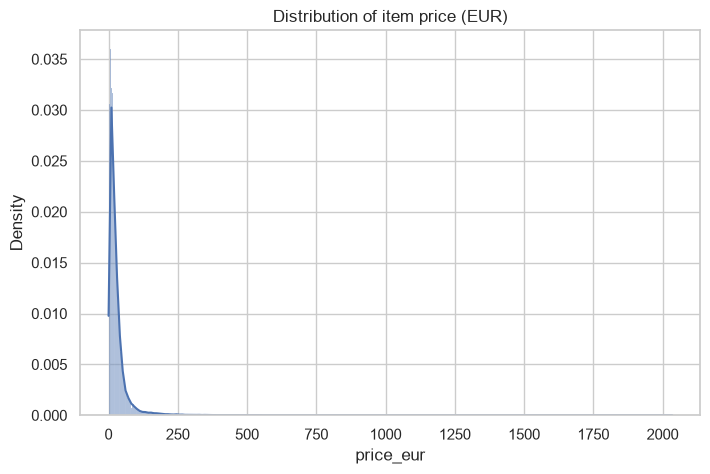

In [36]:
plt.figure(figsize=(8, 5))
sns.histplot(final["price_eur"], stat="density", kde=True)
plt.title("Distribution of item price (EUR)")
plt.show()

### Exercise 4.2 (core) - Boxplot by category

Plot a boxplot([see documentation here](https://seaborn.pydata.org/generated/seaborn.boxplot.html#seaborn.boxplot)) of `price_eur`, with one box per category, using `final_top6`.


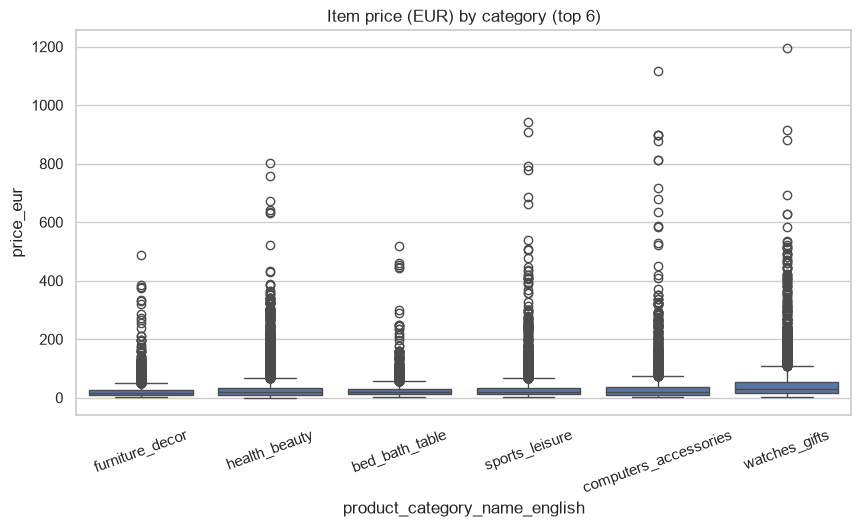

In [37]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=final_top6, x="product_category_name_english", y="price_eur")
plt.title("Item price (EUR) by category (top 6)")
plt.xticks(rotation=20)
plt.show()

### Exercise 4.3 (core) - Correlation heatmap

Plot a `sns.heatmap` ([see documentation here](https://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap)) of the correlation matrix between `price`, `freight_value`, and `price_eur`.
Include the correlation values on the plot (`annot=True`).


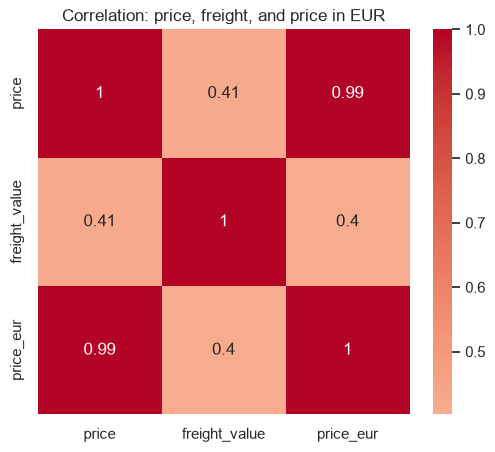

In [38]:
numeric_cols = ["price", "freight_value", "price_eur"]
corr = final[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation: price, freight, and price in EUR")
plt.show()


### Exercise 4.4 (advanced) - The monthly revenue trend

Plot `monthly_revenue_full` (from 3.6) as a line chart over time. Look for two things: the
overall trend, and any single month that stands out sharply from its neighbors. How would you explain the anomaly?


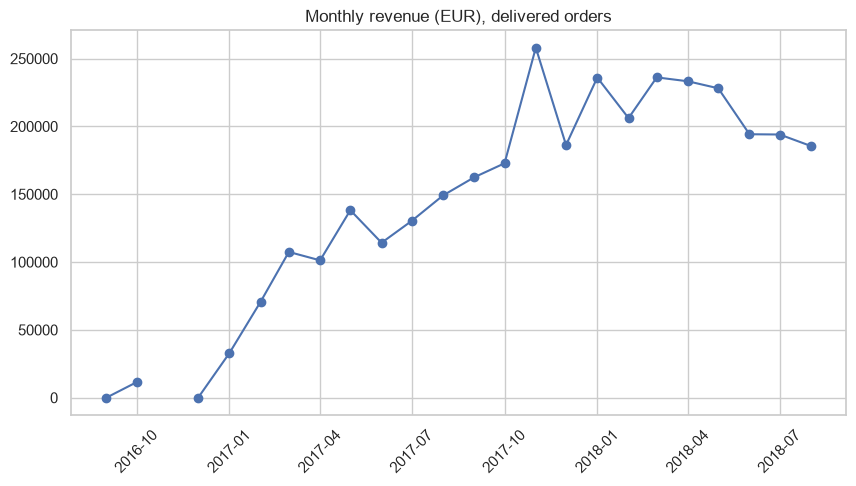

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue_full.index, monthly_revenue_full.values, marker="o")
plt.title("Monthly revenue (EUR), delivered orders")
plt.xticks(rotation=45)
plt.show()
# Revenue grows steadily through the period, with a sharp spike in November
# 2017. Black Friday is a major retail event in Brazil, and this is the kind
# of seasonal spike you'd expect to see in real e-commerce data around it.


## 5. Extending `EDAReport`

In Session 1 you built an `EDAReport` class around a **list of dicts**. Now that we have pandas,
list-of-dicts has done its job - we're switching `EDAReport` to wrap a **DataFrame** directly.

### Exercise 5.1 (core) - Rebuild `EDAReport` around a DataFrame

Define a class `EDAReport` that:
- takes a **DataFrame** in `__init__` and stores it
- has a method `summary()` returning a dict with `"n_rows"`, `"columns"` (list), and `"missing"`
  (a dict of column to missing count)

Test it on `final` from section 3.


In [ ]:
class EDAReport:
    def __init__(self, df):
        self.df = df

    def summary(self):
        return {
            "n_rows": self.df.shape[0],
            "columns": list(self.df.columns),
            "missing": self.df.isna().sum().to_dict(),
        }


report = EDAReport(final)
print(report.summary())


{'n_rows': 110197, 'columns': ['order_id', 'order_item_id', 'product_id', 'price', 'freight_value', 'customer_id', 'order_status', 'order_purchase_timestamp', 'product_category_name', 'product_category_name_english', 'month', 'rate', 'price_eur'], 'missing': {'order_id': 0, 'order_item_id': 0, 'product_id': 0, 'price': 0, 'freight_value': 0, 'customer_id': 0, 'order_status': 0, 'order_purchase_timestamp': 0, 'product_category_name': 1537, 'product_category_name_english': 1559, 'month': 0, 'rate': 0, 'price_eur': 0}}


In [26]:
s = report.summary()
assert s["n_rows"] == len(final)
assert "price_eur" in s["columns"]
print("Looks good!")


Looks good!


### Exercise 5.2 (core) - `plot_distributions`

Add a method `plot_distributions(self, columns=None)` that plots a histogram+KDE for each numeric
column (default: all numeric columns via `self.df.select_dtypes(include="number").columns`).


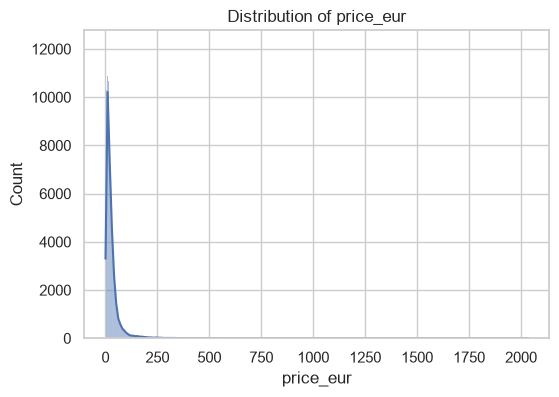

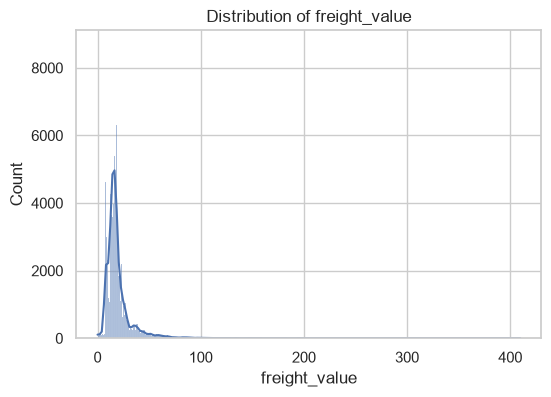

In [ ]:
class EDAReport:
    def __init__(self, df):
        self.df = df

    def summary(self):
        return {
            "n_rows": self.df.shape[0],
            "columns": list(self.df.columns),
            "missing": self.df.isna().sum().to_dict(),
        }

    def plot_distributions(self, columns=None):
        if columns is None:
            columns = self.df.select_dtypes(include="number").columns
        for col in columns:
            plt.figure(figsize=(6, 4))
            sns.histplot(self.df[col].dropna(), kde=True)
            plt.title(f"Distribution of {col}")
            plt.show()


report = EDAReport(final)
report.plot_distributions(columns=["price_eur", "freight_value"])


### Exercise 5.3 (core) - `correlation_heatmap`

Add a method `correlation_heatmap(self)` that plots a `sns.heatmap` of the correlation matrix
across all numeric columns, with `annot=True`.


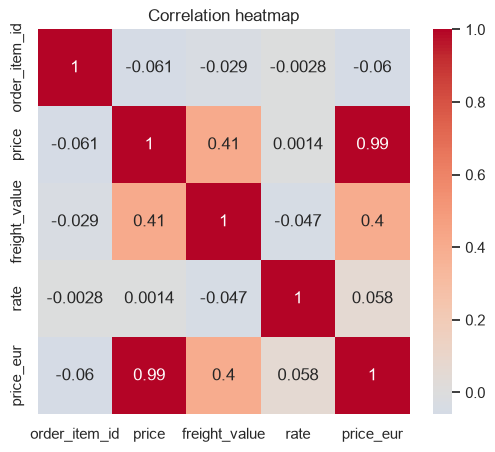

In [ ]:
class EDAReport:
    def __init__(self, df):
        self.df = df

    def summary(self):
        return {
            "n_rows": self.df.shape[0],
            "columns": list(self.df.columns),
            "missing": self.df.isna().sum().to_dict(),
        }

    def plot_distributions(self, columns=None):
        if columns is None:
            columns = self.df.select_dtypes(include="number").columns
        for col in columns:
            plt.figure(figsize=(6, 4))
            sns.histplot(self.df[col].dropna(), kde=True)
            plt.title(f"Distribution of {col}")
            plt.show()

    def correlation_heatmap(self):
        numeric_df = self.df.select_dtypes(include="number")
        plt.figure(figsize=(6, 5))
        sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", center=0)
        plt.title("Correlation heatmap")
        plt.show()


report = EDAReport(final)
report.correlation_heatmap()


<blockquote>
<b>IDs aren't measurements</b>

Look back at the output of `correlation_heatmap()`. One of the flagged
columns is `order_item_id`, a sequential position number identifying an item's place within a
multi-item order (the 1st item, the 2nd item, ...), not a real measurement.

Running outlier detection, or correlation, or a mean, or a z-score, or almost any other
statistic on an ID column doesn't mean anything.

Saying "*This `order_item_id` is 3 standard deviations
from the mean*" isn't a meaningful sentence, even though pandas will happily compute it without
complaint.

**ID columns are labels, not measurements**, even when they happen to be stored as
numbers, an easy mistake to make, since an ID column often decodes as `int64` exactly like
genuinely numeric data, and `select_dtypes(include="number")` can't tell the difference.
</blockquote>


### Exercise 5.4 (core) - `detect_outliers`

Add a method `detect_outliers(self)` using the **IQR method**: for each numeric column, a value
is an outlier if it falls below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`. Return a dict mapping each
numeric column name to its **count** of outliers.


In [ ]:
class EDAReport:
    def __init__(self, df):
        self.df = df

    def summary(self):
        return {
            "n_rows": self.df.shape[0],
            "columns": list(self.df.columns),
            "missing": self.df.isna().sum().to_dict(),
        }

    def plot_distributions(self, columns=None):
        if columns is None:
            columns = self.df.select_dtypes(include="number").columns
        for col in columns:
            plt.figure(figsize=(6, 4))
            sns.histplot(self.df[col].dropna(), kde=True)
            plt.title(f"Distribution of {col}")
            plt.show()

    def correlation_heatmap(self):
        numeric_df = self.df.select_dtypes(include="number")
        plt.figure(figsize=(6, 5))
        sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", center=0)
        plt.title("Correlation heatmap")
        plt.show()

    def detect_outliers(self):
        outlier_counts = {}
        for col in self.df.select_dtypes(include="number").columns:
            series = self.df[col]
            q1, q3 = series.quantile(0.25), series.quantile(0.75)
            iqr = q3 - q1
            lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            outlier_counts[col] = ((series < lower) | (series > upper)).sum()
        return outlier_counts


report = EDAReport(final)
print(report.detect_outliers())


{'order_item_id': np.int64(13719), 'price': np.int64(8162), 'freight_value': np.int64(11811), 'rate': np.int64(0), 'price_eur': np.int64(8308)}


In [30]:
outliers = report.detect_outliers()
assert "price_eur" in outliers
print("Looks good!")


Looks good!


### Exercise 5.5 (advanced) - Support both IQR and z-score methods

Extend `detect_outliers` to accept a `method` parameter: `"iqr"` (as above, the default) or
`"zscore"` (flag values where `abs(z-score) > 3`). Return a dict mapping each column to a
**boolean mask** instead of just a count, so a caller can actually inspect the flagged rows.


In [ ]:
class EDAReportV2(EDAReport):
    def detect_outliers(self, method="iqr"):
        masks = {}
        for col in self.df.select_dtypes(include="number").columns:
            series = self.df[col]
            if method == "iqr":
                q1, q3 = series.quantile(0.25), series.quantile(0.75)
                iqr = q3 - q1
                lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
                mask = (series < lower) | (series > upper)
            elif method == "zscore":
                z_scores = (series - series.mean()) / series.std()
                mask = z_scores.abs() > 3
            else:
                raise ValueError(f"Unknown method: {method!r}")
            masks[col] = mask.fillna(False)
        return masks


report2 = EDAReportV2(final)
masks = report2.detect_outliers(method="zscore")
print({col: mask.sum() for col, mask in masks.items()})


{'order_item_id': np.int64(1841), 'price': np.int64(1930), 'freight_value': np.int64(2004), 'rate': np.int64(0), 'price_eur': np.int64(1902)}


---

**Next session**: we bring in `scipy` to add a statistical layer - for the pure statistical
mechanics (fitting distributions, hypothesis testing, correlation with significance) we'll work
with a clean, well-known real dataset. For finishing `EDAReport` itself, we'll come back to this
Olist data and pick up right where today left off.
